In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import xarray as xr

import uncertainties.unumpy as unp

from acspype import ACSDev, ACSTSCor

import acspype.processing as acsproc

In [2]:
data_fp = '../../dev_tools/test_files/TEST_SHIMADA_202405.nc'
dev_fp = '../../dev_tools/test_files/ACS-00412_2023-05-10.dev'

In [3]:
acs = xr.open_dataset(data_fp)
acs = acs.drop_vars([v for v in acs.data_vars if '_dark' in v], errors = 'ignore')
acs = acs.where(acs.seawater_state == 0, drop = True)
acs = acs.where(acs.elapsed_time > 60 * 1000, drop = True)
dev = ACSDev(dev_fp)

In [4]:
acs = acs.sel(time = acs.time.values[200:202], method = 'nearest')

In [5]:
acs['internal_temperature'] = acsproc.compute_internal_temperature(counts = acs.raw_internal_temperature,return_uncertainty=True)

acs['a_uncorr'] = (['time','a_wavelength'],acsproc.compute_uncorrected(signal_counts=acs.a_signal,
                                                   reference_counts=acs.a_reference,
                                                   path_length = dev.path_length, return_uncertainty=True))

acs['c_uncorr'] = (['time','c_wavelength'],acsproc.compute_uncorrected(signal_counts = acs.c_signal,
                                                   reference_counts = acs.c_reference,
                                                   path_length = dev.path_length, return_uncertainty=True))

acs['a_m'] = acsproc.compute_measured(uncorrected = acs.a_uncorr,
                                                    internal_temperature = acs.internal_temperature,
                                                    offset = dev.a_offset,
                                                    func_delta_t = dev.func_a_delta_t, return_uncertainty=True)

acs['c_m'] = acsproc.compute_measured(uncorrected = acs.c_uncorr,
                                                    internal_temperature = acs.internal_temperature,
                                                    offset = dev.c_offset,
                                                    func_delta_t=dev.func_c_delta_t, return_uncertainty=True)

tscor = ACSTSCor().to_xarray()  ## Load the TSCor coefficients as an xarray dataset.

# TSCor coeffs for absorption.
psi_t_a = tscor.psi_t.sel(wavelength=acs.a_wavelength)
psi_s_a = tscor.psi_s_a.sel(wavelength=acs.a_wavelength)

# TSCor coeffs for attenuation.
psi_t_c = tscor.psi_t.sel(wavelength=acs.c_wavelength)
psi_s_c = tscor.psi_s_c.sel(wavelength=acs.c_wavelength)

sigma_psi_t_c = tscor.sigma_psi_t.sel(wavelength = acs.c_wavelength.values)
sigma_psi_t_a = tscor.sigma_psi_t.sel(wavelength = acs.a_wavelength.values)
sigma_psi_s_c = tscor.sigma_psi_s_a.sel(wavelength = acs.c_wavelength.values)
sigma_psi_s_a = tscor.sigma_psi_s_a.sel(wavelength = acs.a_wavelength.values)

tcal = dev.tcal  # The reference temperature value in the device file.

acs['a_mts'] = acsproc.ts_correction(measured = acs.a_m,
                                     temperature = acs.sea_water_temperature,
                                     salinity = acs.sea_water_practical_salinity,
                                     psi_temperature = psi_t_a,
                                     psi_salinity= psi_s_a,
                                     tcal = tcal,
                                     return_uncertainty=True, unc_temperature = 0.2, unc_salinity = 0.2, sigma_psi_salinity=sigma_psi_s_a, sigma_psi_temperature=sigma_psi_t_a)

acs['c_mts'] = acsproc.ts_correction(measured = acs.c_m,
                                     temperature = acs.sea_water_temperature,
                                     salinity = acs.sea_water_practical_salinity,
                                     psi_temperature= psi_t_c,
                                     psi_salinity = psi_s_c,
                                     tcal = tcal,
                                     return_uncertainty=True, unc_temperature = 0.2, unc_salinity = 0.2, sigma_psi_salinity=sigma_psi_s_c, sigma_psi_temperature=sigma_psi_t_c)

ex = acs.sel(time = acs.time.values[0], method = 'nearest')
ex = ex.sel(c_wavelength = slice(401,716), a_wavelength = slice(401,716))

a = unp.nominal_values(ex.a_mts.values)
a_unc = unp.std_devs(ex.a_mts.values)
a_wvl = ex.a_wavelength.values
ads = xr.Dataset()
ads = ads.assign_coords({'wvl': a_wvl})
ads['a'] = (['wvl'], a)
ads['unc'] = (['wvl'], a_unc)

c = unp.nominal_values(ex.c_mts.values)
c_unc = unp.std_devs(ex.c_mts.values)
c_wvl = ex.c_wavelength.values
cds = xr.Dataset()
cds = cds.assign_coords({'wvl': c_wvl})
cds['c'] = (['wvl'], c)
cds['unc'] = (['wvl'], c_unc)
cds['c'] = cds['c'].rolling({"wvl":3}, center = True, min_periods = 1).median()


ads_w_acs = ads
cds_w_acs = cds

In [6]:
acs['internal_temperature'] = acsproc.compute_internal_temperature(counts = acs.raw_internal_temperature,return_uncertainty=True)

acs['a_uncorr'] = (['time','a_wavelength'],acsproc.compute_uncorrected(signal_counts=acs.a_signal,
                                                   reference_counts=acs.a_reference,
                                                   path_length = dev.path_length, return_uncertainty=True, unc = 0))

acs['c_uncorr'] = (['time','c_wavelength'],acsproc.compute_uncorrected(signal_counts = acs.c_signal,
                                                   reference_counts = acs.c_reference,
                                                   path_length = dev.path_length, return_uncertainty=True, unc = 0))

acs['a_m'] = acsproc.compute_measured(uncorrected = acs.a_uncorr,
                                                    internal_temperature = acs.internal_temperature,
                                                    offset = dev.a_offset,
                                                    func_delta_t = dev.func_a_delta_t, return_uncertainty=True)

acs['c_m'] = acsproc.compute_measured(uncorrected = acs.c_uncorr,
                                                    internal_temperature = acs.internal_temperature,
                                                    offset = dev.c_offset,
                                                    func_delta_t=dev.func_c_delta_t, return_uncertainty=True)

tscor = ACSTSCor().to_xarray()  ## Load the TSCor coefficients as an xarray dataset.

# TSCor coeffs for absorption.
psi_t_a = tscor.psi_t.sel(wavelength=acs.a_wavelength)
psi_s_a = tscor.psi_s_a.sel(wavelength=acs.a_wavelength)

# TSCor coeffs for attenuation.
psi_t_c = tscor.psi_t.sel(wavelength=acs.c_wavelength)
psi_s_c = tscor.psi_s_c.sel(wavelength=acs.c_wavelength)

sigma_psi_t_c = tscor.sigma_psi_t.sel(wavelength = acs.c_wavelength.values)
sigma_psi_t_a = tscor.sigma_psi_t.sel(wavelength = acs.a_wavelength.values)
sigma_psi_s_c = tscor.sigma_psi_s_a.sel(wavelength = acs.c_wavelength.values)
sigma_psi_s_a = tscor.sigma_psi_s_a.sel(wavelength = acs.a_wavelength.values)

tcal = dev.tcal  # The reference temperature value in the device file.

acs['a_mts'] = acsproc.ts_correction(measured = acs.a_m,
                                     temperature = acs.sea_water_temperature,
                                     salinity = acs.sea_water_practical_salinity,
                                     psi_temperature = psi_t_a,
                                     psi_salinity= psi_s_a,
                                     tcal = tcal,
                                     return_uncertainty=True, unc_temperature = 0.2, unc_salinity = 0.2, sigma_psi_salinity=sigma_psi_s_a, sigma_psi_temperature=sigma_psi_t_a)

acs['c_mts'] = acsproc.ts_correction(measured = acs.c_m,
                                     temperature = acs.sea_water_temperature,
                                     salinity = acs.sea_water_practical_salinity,
                                     psi_temperature= psi_t_c,
                                     psi_salinity = psi_s_c,
                                     tcal = tcal,
                                     return_uncertainty=True, unc_temperature = 0.2, unc_salinity = 0.2, sigma_psi_salinity=sigma_psi_s_c, sigma_psi_temperature=sigma_psi_t_c)

ex = acs.sel(time = acs.time.values[0], method = 'nearest')
ex = ex.sel(c_wavelength = slice(401,716), a_wavelength = slice(401,716))

a = unp.nominal_values(ex.a_mts.values)
a_unc = unp.std_devs(ex.a_mts.values)
a_wvl = ex.a_wavelength.values
ads = xr.Dataset()
ads = ads.assign_coords({'wvl': a_wvl})
ads['a'] = (['wvl'], a)
ads['unc'] = (['wvl'], a_unc)

c = unp.nominal_values(ex.c_mts.values)
c_unc = unp.std_devs(ex.c_mts.values)
c_wvl = ex.c_wavelength.values
cds = xr.Dataset()
cds = cds.assign_coords({'wvl': c_wvl})
cds['c'] = (['wvl'], c)
cds['unc'] = (['wvl'], c_unc)
cds['c'] = cds['c'].rolling({"wvl":3}, center = True, min_periods = 1).median()

ads_no_acs = ads
cds_no_acs = cds

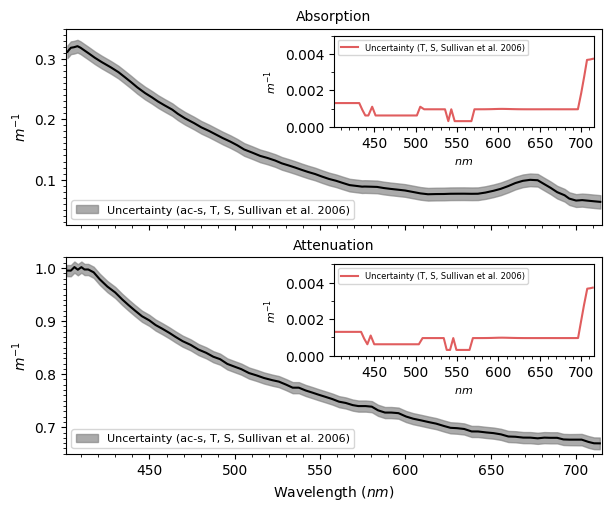

In [7]:
fig, ax = plt.subplots(2,1, figsize = (6,5), constrained_layout = True, sharex = True)

ax[0].set_title('Absorption',fontsize = 10)
ax[0].set_ylabel(r'$m^{-1}$')
ax[0].fill_between(ads_w_acs.wvl, ads_w_acs.a - ads_w_acs.unc, ads_w_acs.a+ads_w_acs.unc, zorder = 1, color = 'tab:grey', alpha = 0.65, label = 'Uncertainty (ac-s, T, S, Sullivan et al. 2006)')
ax[0].plot(ads_w_acs.wvl, ads_w_acs.a, zorder = 1, color = 'black')
ax[0].set_ylim(0.025,0.35)
ax[0].yaxis.set_major_locator(MultipleLocator(0.1))
ax[0].yaxis.set_minor_locator(MultipleLocator(0.01))
ax[0].legend(loc = 'lower left', fontsize = 8)

x1,x2,y1,y2 = 401,715,0,0.005
axins0 = ax[0].inset_axes([0.5, 0.5, 0.485, 0.465], xlim=(x1, x2), ylim=(y1, y2))
axins0.plot(ads_no_acs.wvl, ads_no_acs.unc, color = 'tab:red',alpha = 0.75, label = 'Uncertainty (T, S, Sullivan et al. 2006)')
axins0.legend(loc = 'upper left', fontsize = 6)
axins0.set_xlim(401,715)
axins0.set_xlabel(r'$nm$',fontsize = 8)
axins0.set_ylabel(r'$m^{-1}$', fontsize = 8)
axins0.xaxis.set_major_locator(MultipleLocator(50))
axins0.xaxis.set_minor_locator(MultipleLocator(10))
axins0.yaxis.set_major_locator(MultipleLocator(0.002))
axins0.yaxis.set_minor_locator(MultipleLocator(0.001))


ax[1].set_title('Attenuation', fontsize = 10)
ax[1].set_ylabel(r'$m^{-1}$')
ax[1].fill_between(cds_w_acs.wvl, cds_w_acs.c - cds_w_acs.unc, cds_w_acs.c + cds_w_acs.unc, zorder = 0, color = 'tab:grey', alpha = 0.65, label = 'Uncertainty (ac-s, T, S, Sullivan et al. 2006)')
ax[1].plot(cds_w_acs.wvl, cds_w_acs.c, zorder = 1, color = 'black')
ax[1].set_ylim(0.65,1.02)
ax[1].yaxis.set_major_locator(MultipleLocator(0.1))
ax[1].yaxis.set_minor_locator(MultipleLocator(0.01))
ax[1].legend(loc = 'lower left', fontsize = 8)

x1,x2,y1,y2 = 401,715,0,0.005
axins1= ax[1].inset_axes([0.5, 0.5, 0.485, 0.465], xlim=(x1, x2), ylim=(y1, y2))
axins1.plot(cds_no_acs.wvl, cds_no_acs.unc, color = 'tab:red',alpha = 0.75, label = 'Uncertainty (T, S, Sullivan et al. 2006)')
axins1.legend(loc = 'upper left', fontsize = 6)
axins1.set_xlim(401,715)
axins1.set_xlabel(r'$nm$',fontsize = 8)
axins1.set_ylabel(r'$m^{-1}$', fontsize = 8)
axins1.xaxis.set_major_locator(MultipleLocator(50))
axins1.xaxis.set_minor_locator(MultipleLocator(10))
axins1.yaxis.set_major_locator(MultipleLocator(0.002))
axins1.yaxis.set_minor_locator(MultipleLocator(0.001))


ax[-1].set_xlim(401,715)
ax[-1].xaxis.set_major_locator(MultipleLocator(50))
ax[-1].xaxis.set_minor_locator(MultipleLocator(10))
ax[-1].set_xlabel(r'Wavelength ($nm$)')


plt.savefig('uncertainty.jpg', dpi = 1200)